In [14]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

LOG_PATH = Path("../log/")

log_files = sorted(LOG_PATH.glob("*.h5"))
for i, f in enumerate(log_files):
    print(f"{i}: {f.name}")

0: 20260319_111919.h5
1: 20260319_111949.h5
2: 20260319_112046.h5
3: 20260319_112134.h5
4: 20260319_112150.h5
5: 20260319_112940.h5
6: 20260319_113144.h5


In [15]:
# pick file by index or set path directly
path = log_files[-1]

with h5py.File(path, "r") as f:
    t   = f["t"][:]
    q1  = f["q1"][:]
    q2  = f["q2"][:]
    dq1 = f["dq1"][:]
    dq2 = f["dq2"][:]
    u   = f["u"][:]

print(f"Loaded: {path.name}  |  {len(t)} steps  |  duration {t[-1]:.2f}s")

Loaded: 20260319_113144.h5  |  5000 steps  |  duration 10.00s


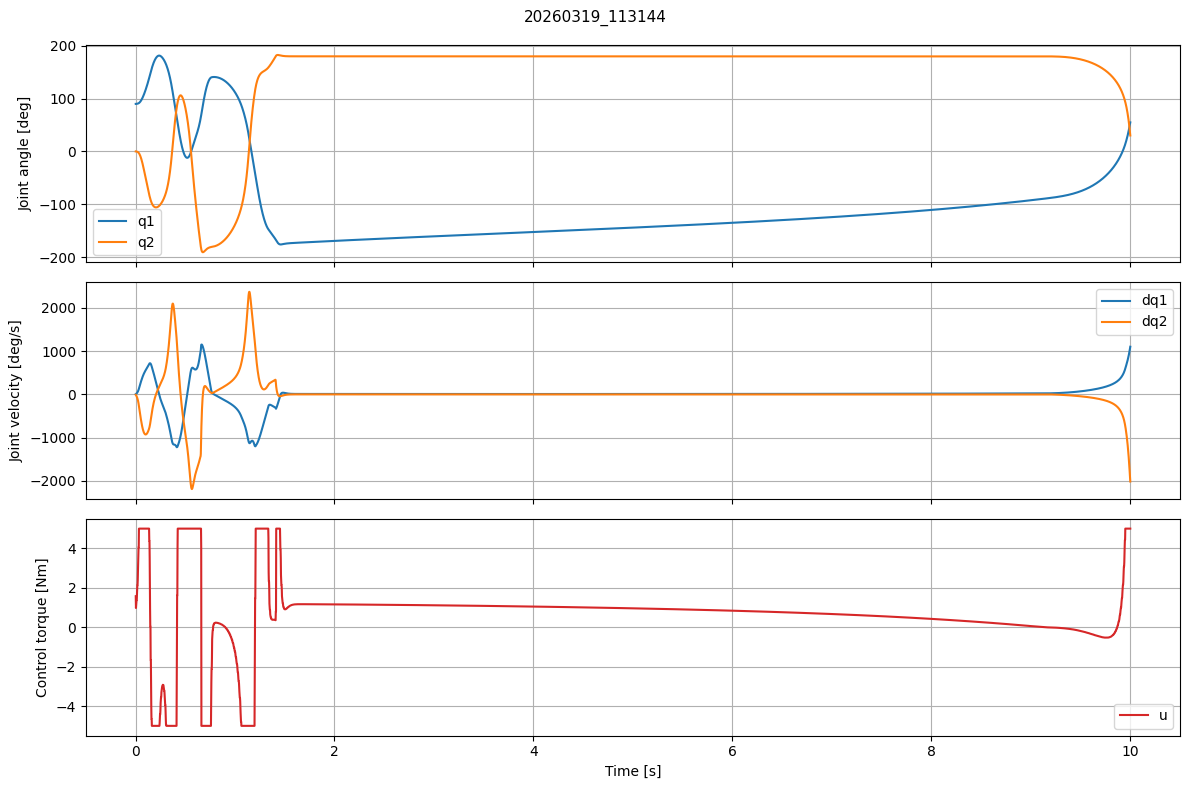

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle(path.stem, fontsize=11)

axes[0].plot(t, np.degrees(q1), label="q1")
axes[0].plot(t, np.degrees(q2), label="q2")
axes[0].set_ylabel("Joint angle [deg]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, np.degrees(dq1), label="dq1")
axes[1].plot(t, np.degrees(dq2), label="dq2")
axes[1].set_ylabel("Joint velocity [deg/s]")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(t, u, color="tab:red", label="u")
axes[2].set_ylabel("Control torque [Nm]")
axes[2].set_xlabel("Time [s]")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()